Loaded meta from: ./EUR/wavestitchplus/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/prepared/meta.json
Time column: time
Target columns (15): ['cpu_limit', 'cpu_usage', 'n', 'c', 'ram_limit_mb', 'ram_usage_mb', 'lat50_ms', 'lat66_ms', 'lat75_ms', 'lat80_ms', 'lat90_ms', 'lat95_ms', 'lat98_ms', 'lat99_ms', 'lat100_ms']

Data shapes: GT=(1158, 22), WaveStitch+=(1158, 22), Final cleaned=(1158, 22)
[INFO] Time sample: 1647563471 (type: int64)
[INFO] Detected Unix timestamp (seconds)
[INFO] Time range: 2022-03-18 00:31:11 to 2022-03-18 17:25:16
[INFO] Duration: 0 days 16:54:05

[PLOTTING] Individual feature plots...


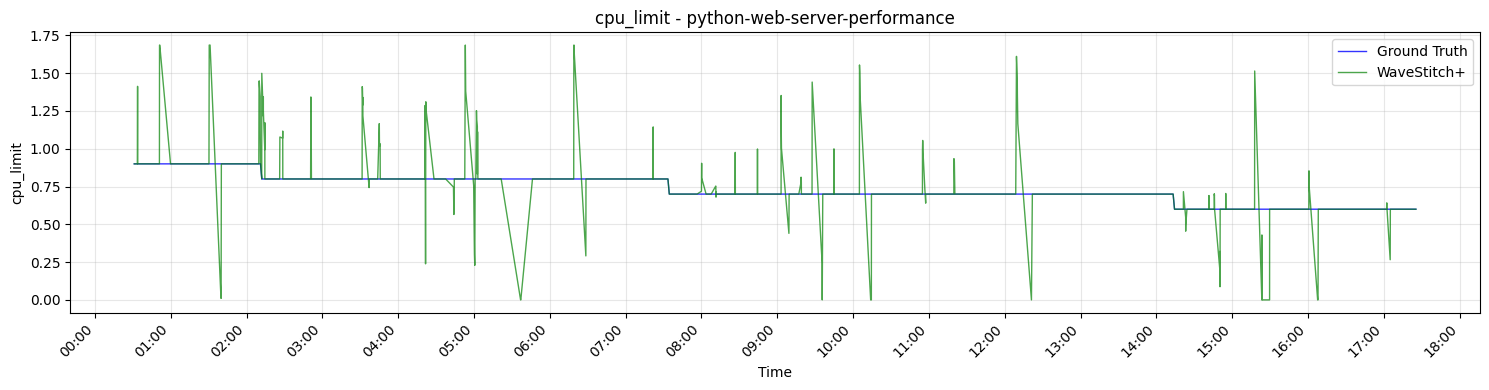

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/cpu_limit.png


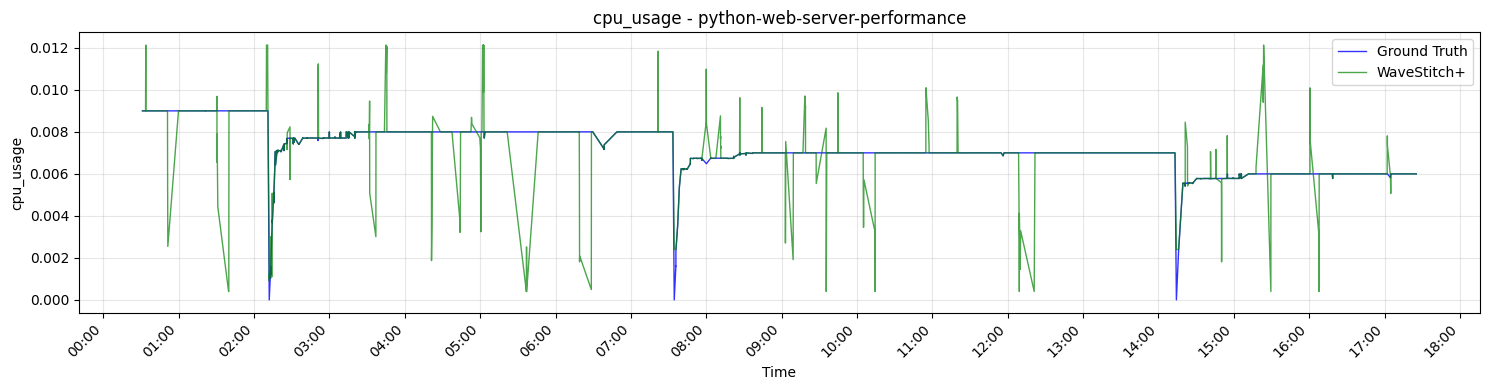

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/cpu_usage.png


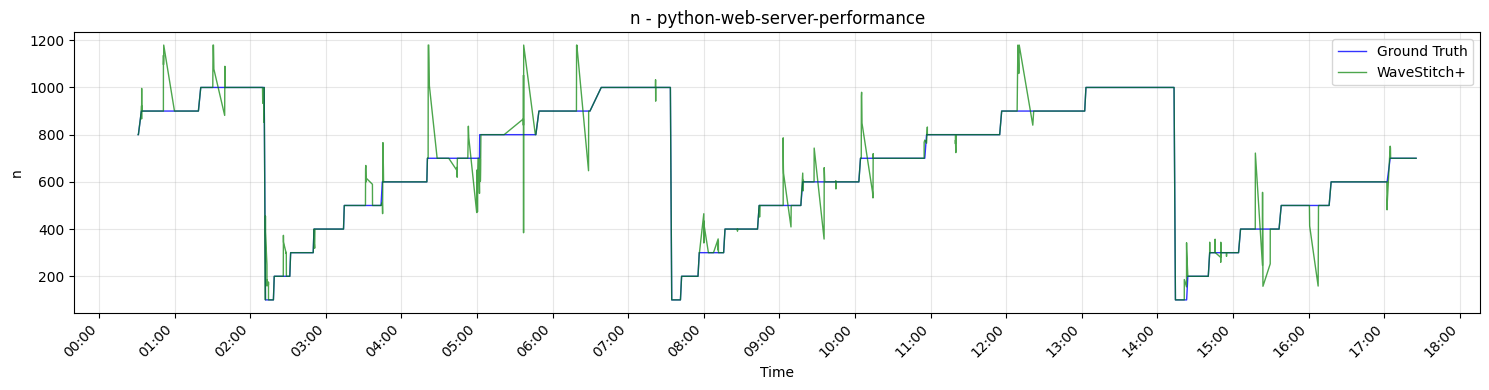

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/n.png


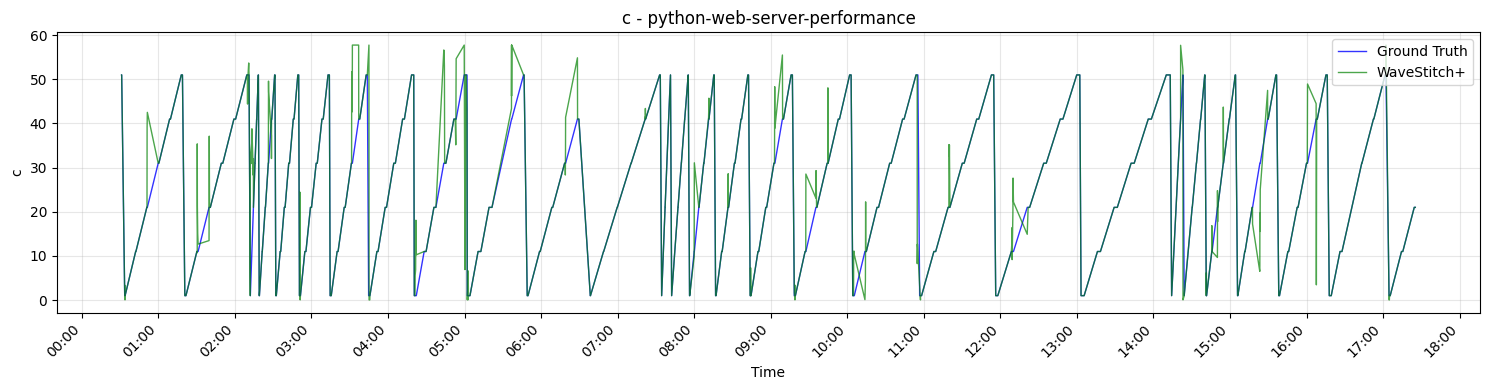

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/c.png


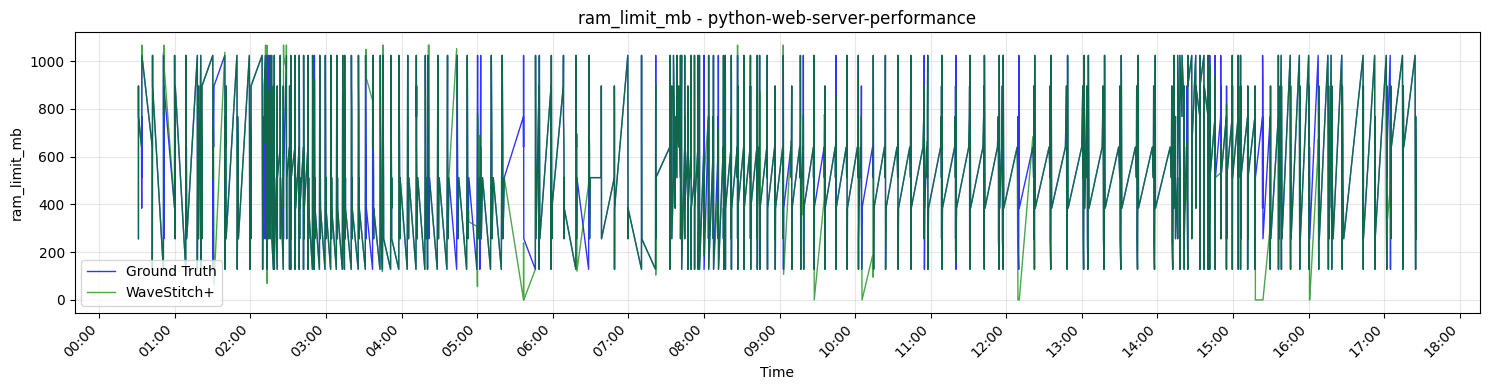

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/ram_limit_mb.png


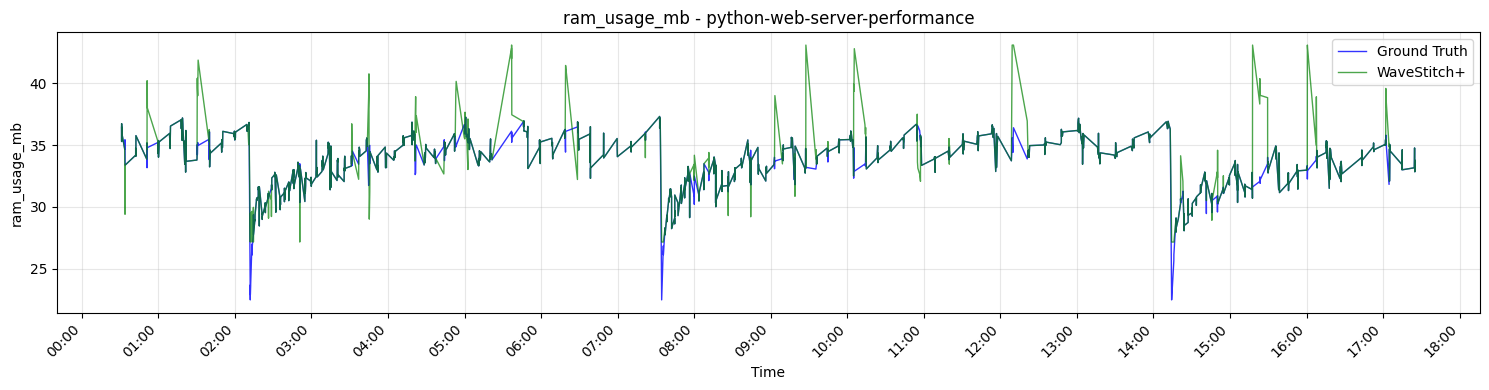

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/ram_usage_mb.png


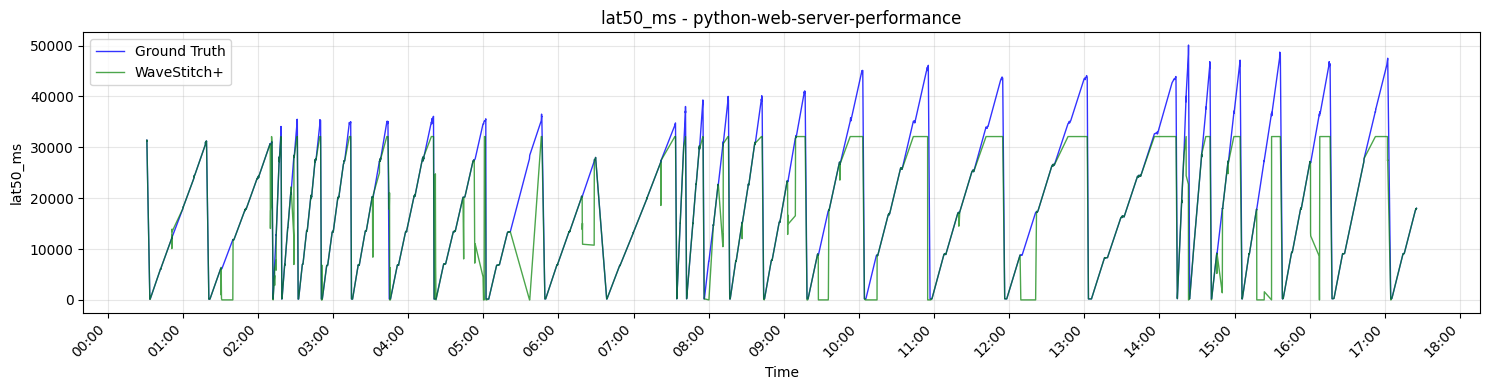

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/lat50_ms.png


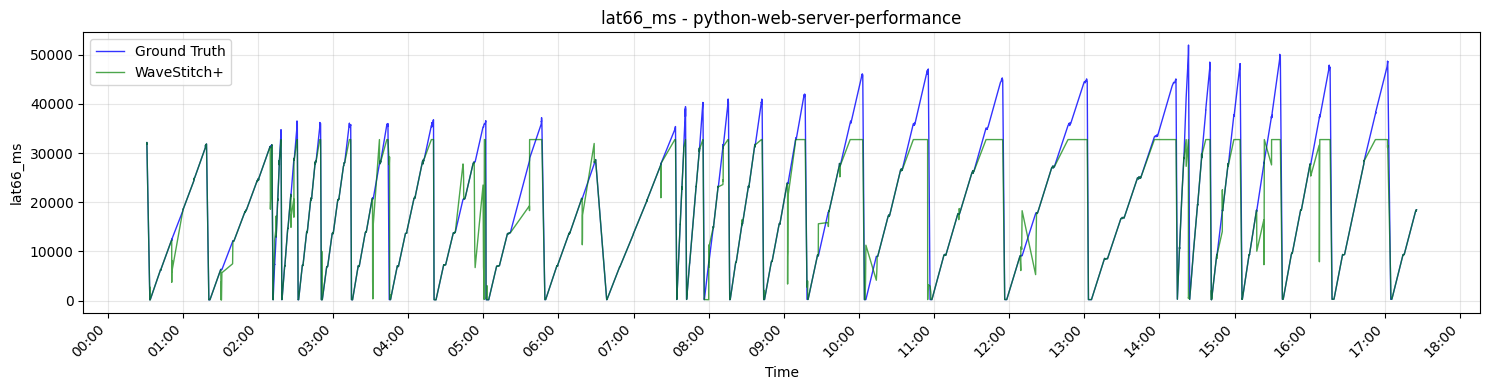

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/lat66_ms.png


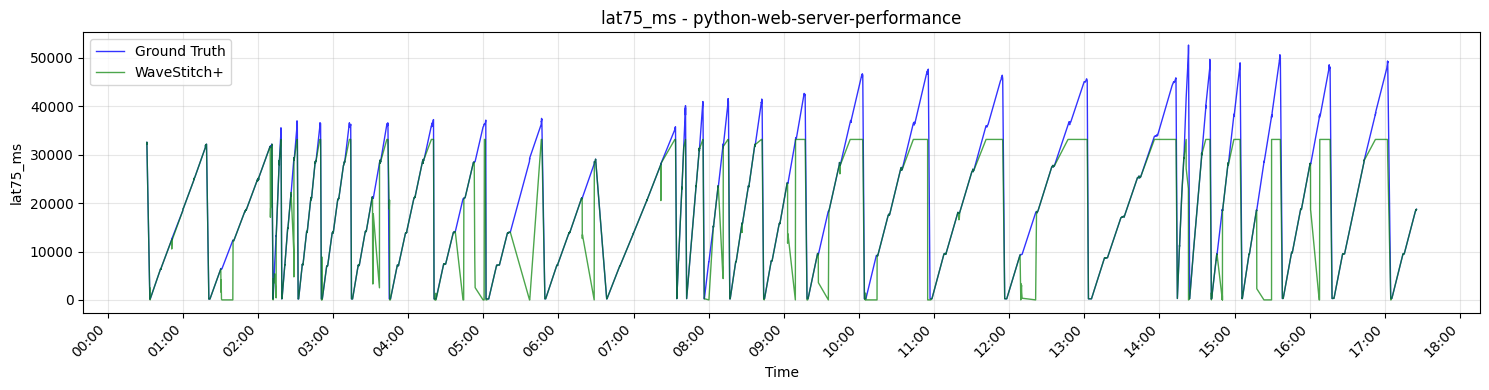

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/lat75_ms.png


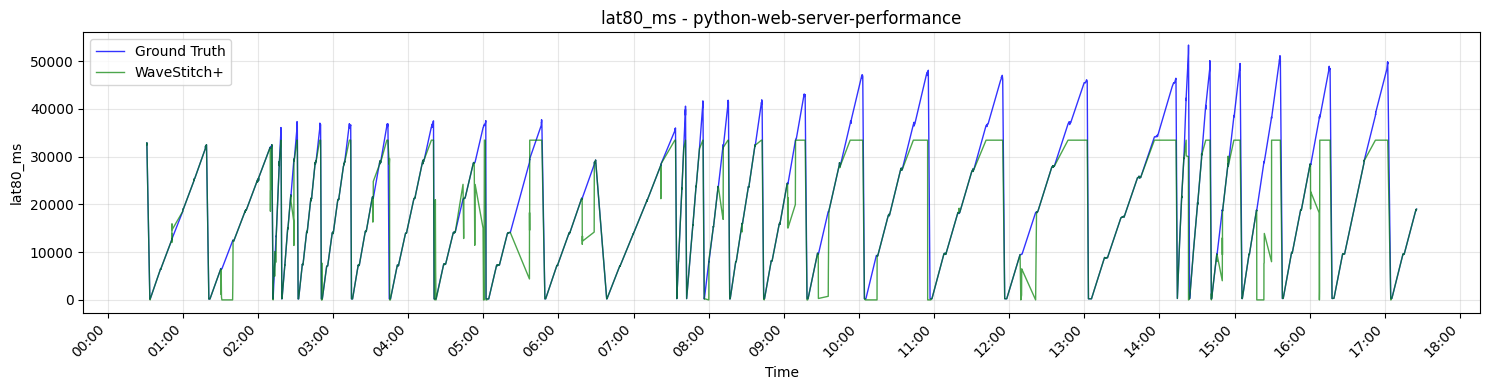

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/lat80_ms.png


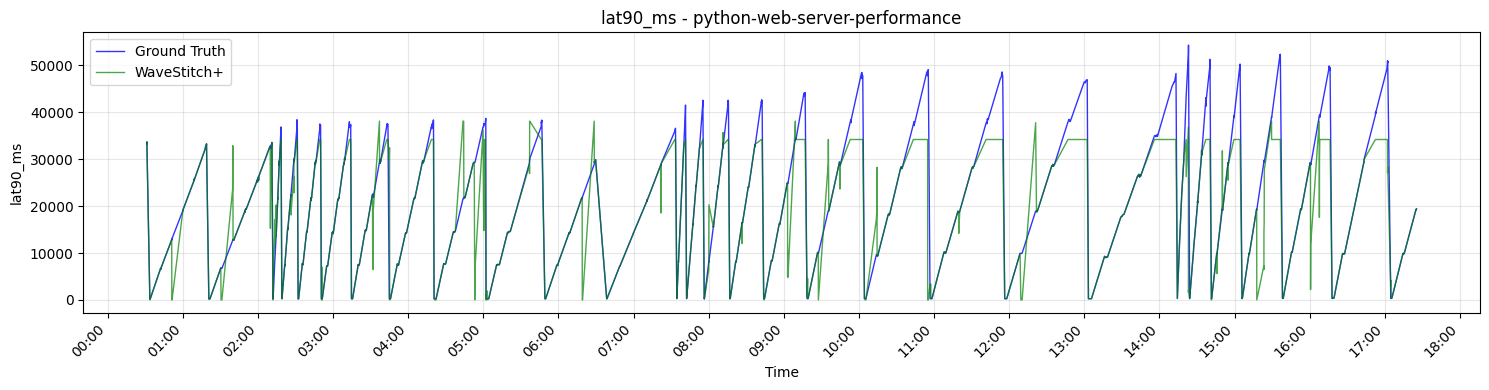

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/lat90_ms.png


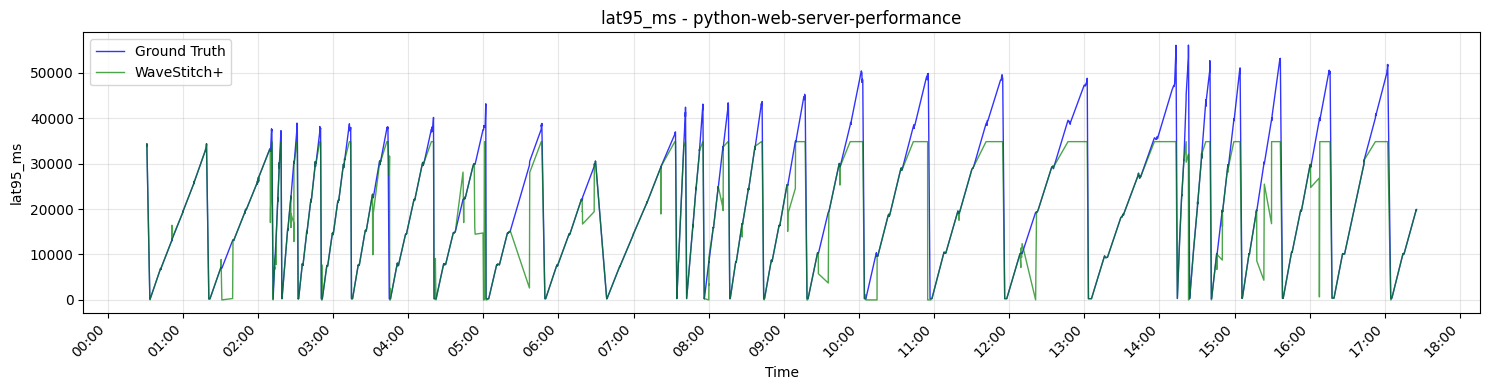

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/lat95_ms.png


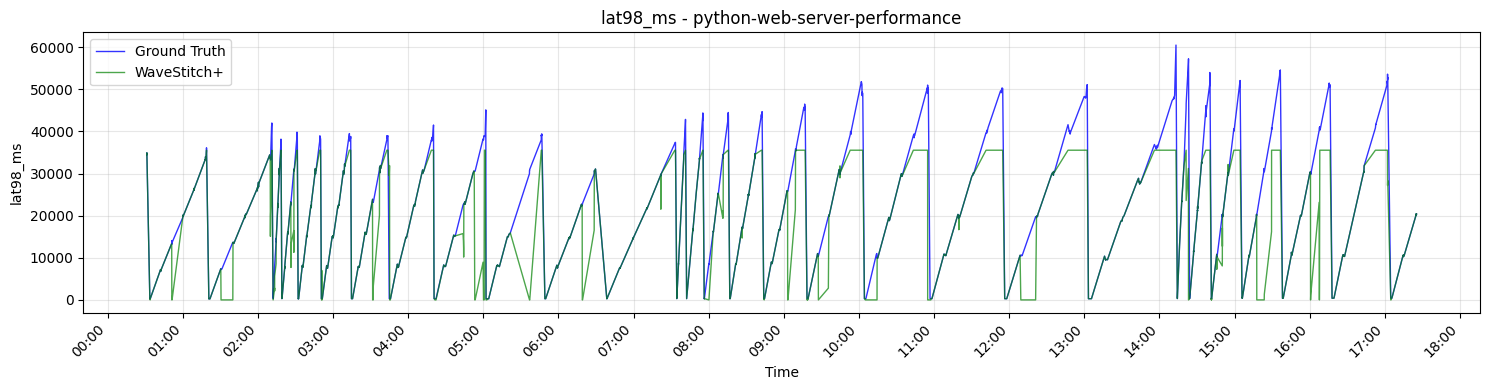

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/lat98_ms.png


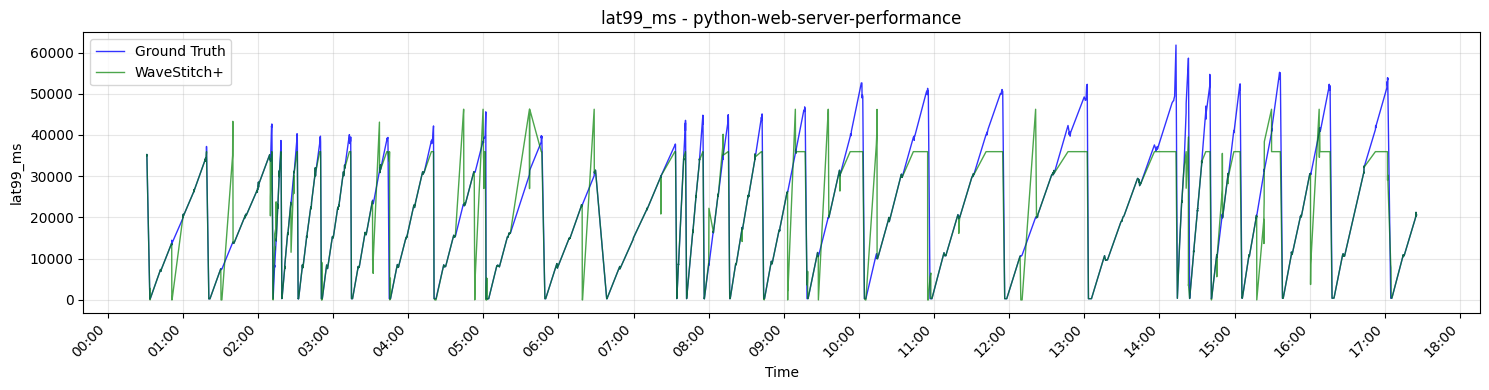

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/lat99_ms.png


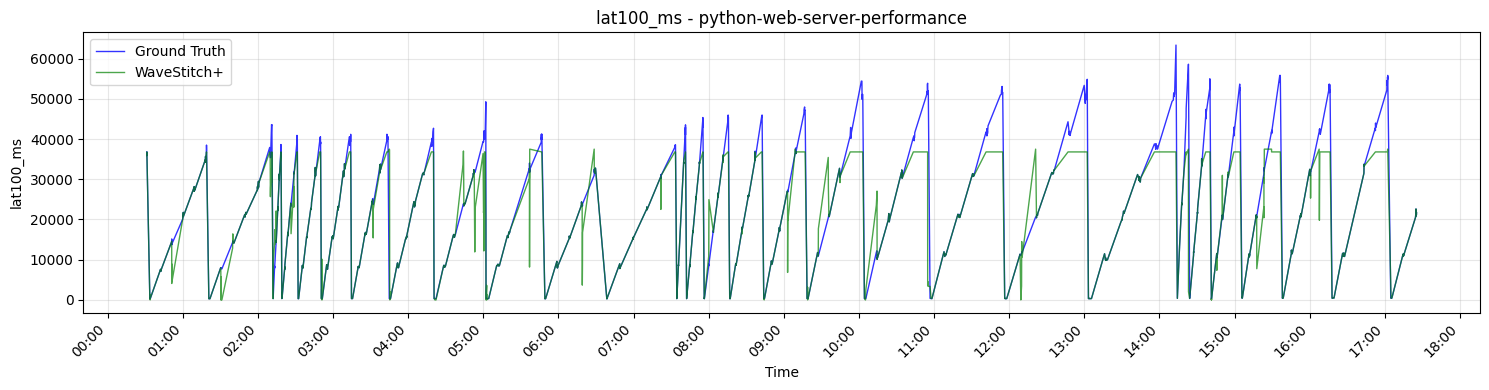

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/lat100_ms.png

[PLOTTING] Grid plot...


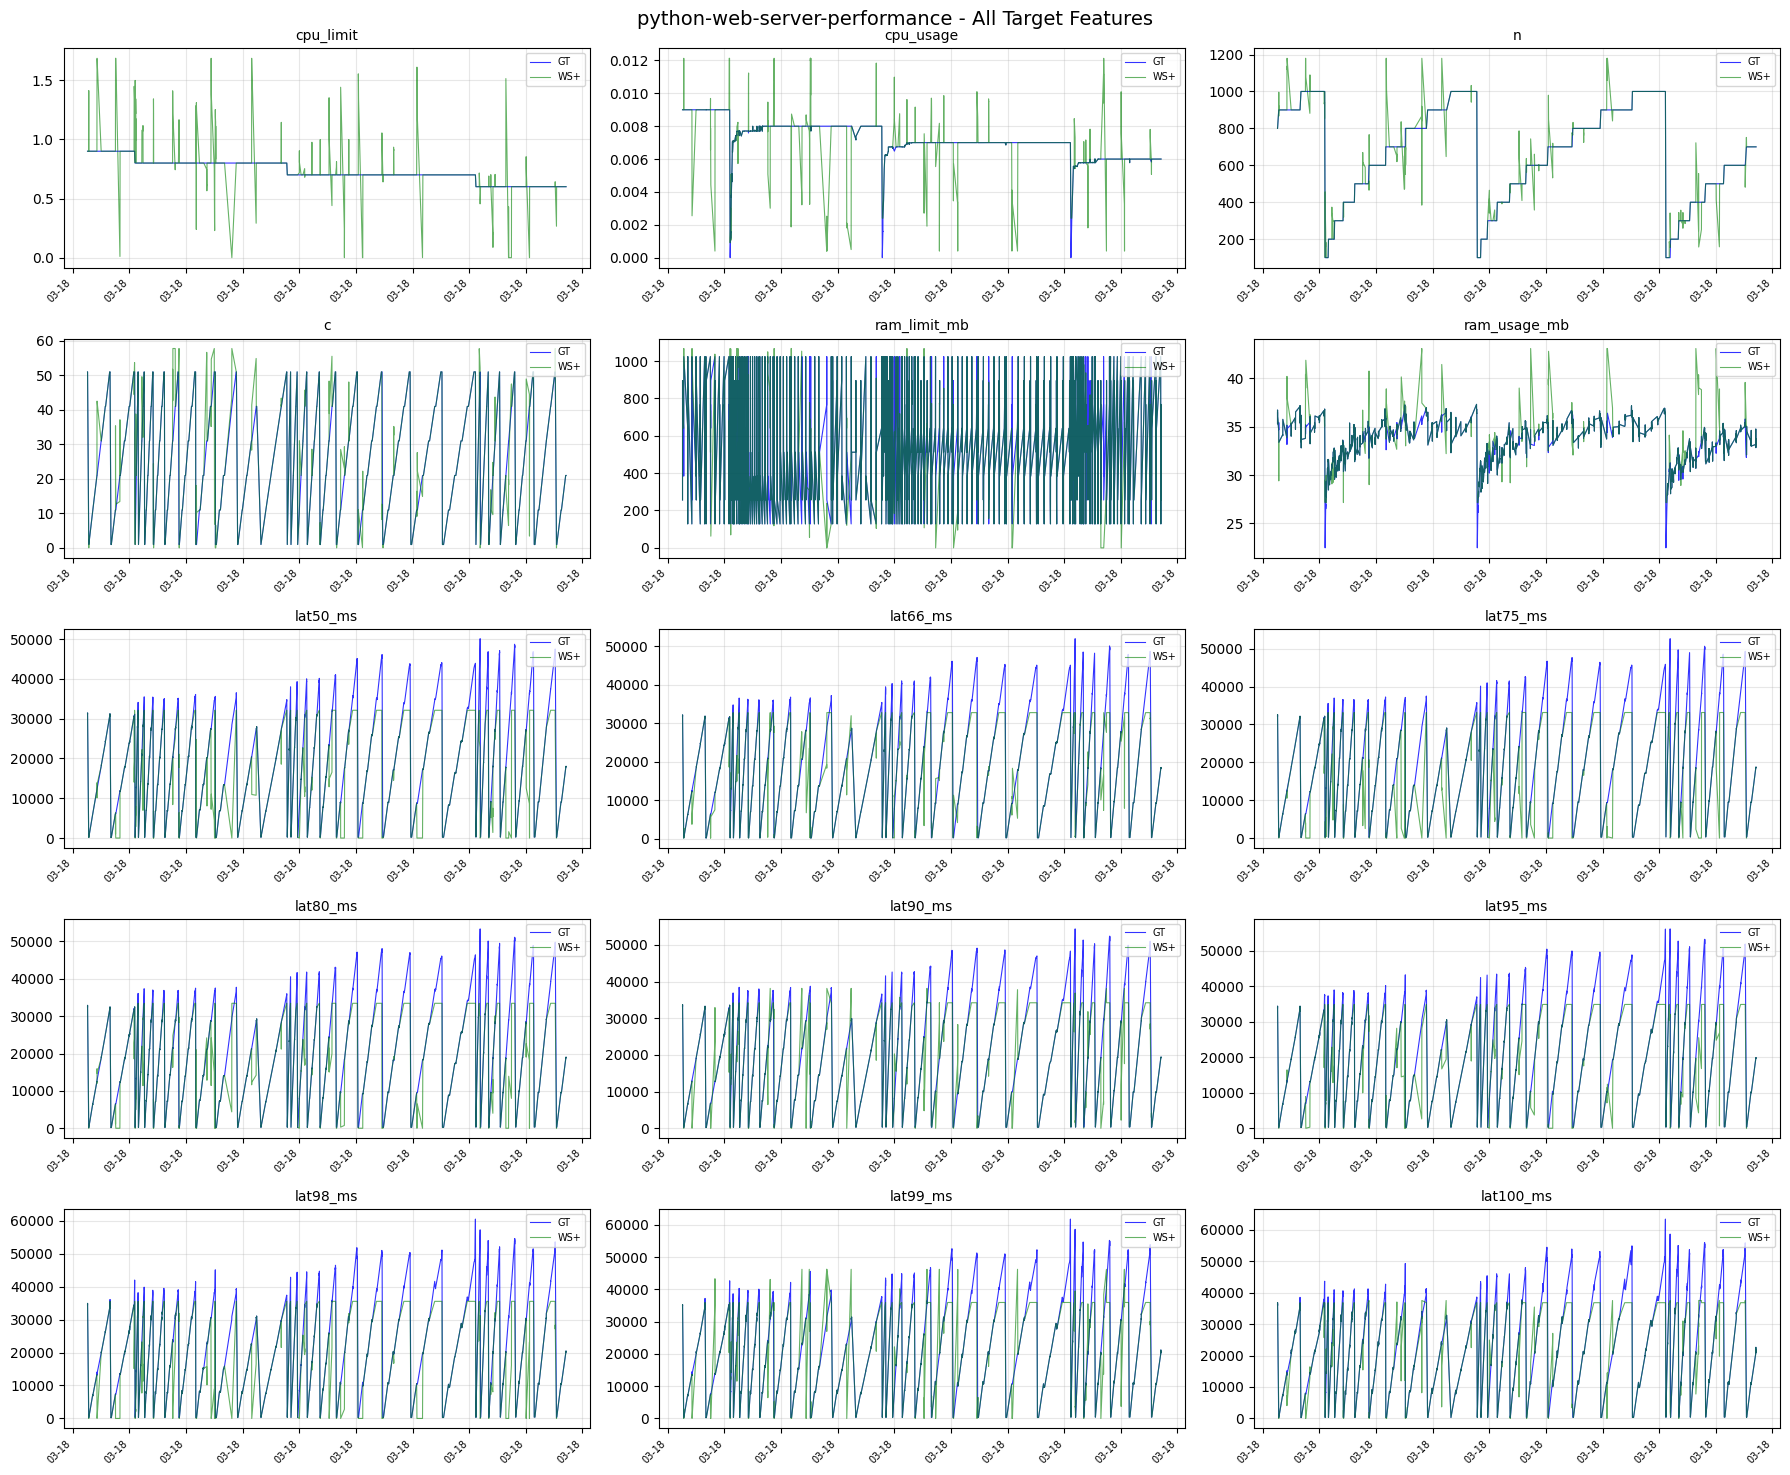

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/all_features_grid.png

[PLOTTING] Grouped plots...


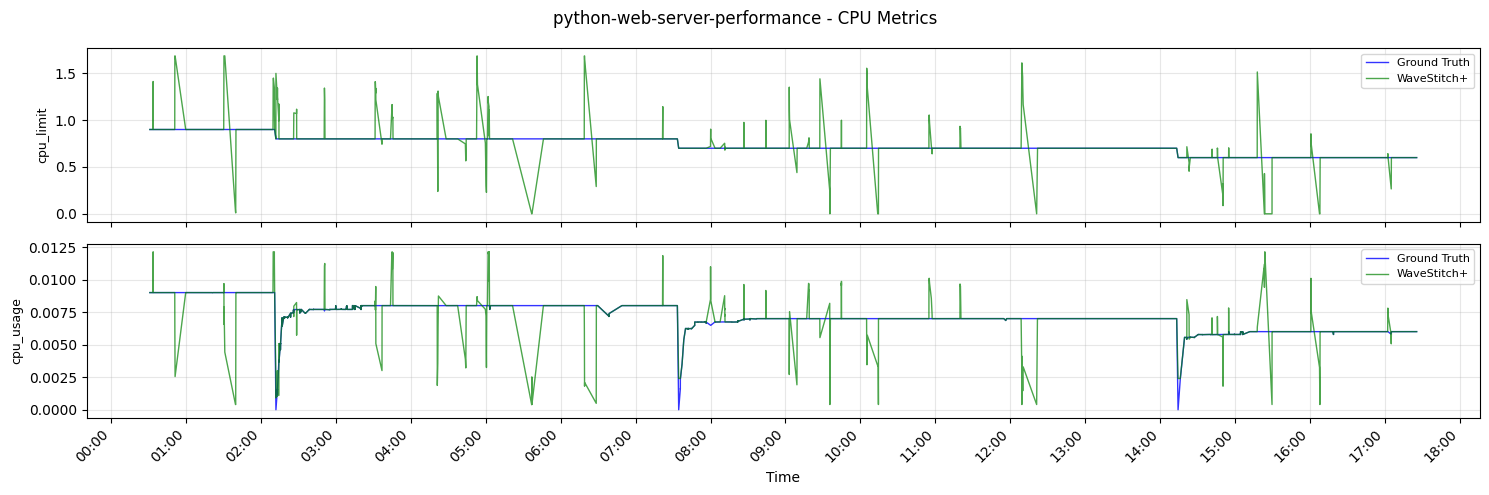

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/group_cpu.png


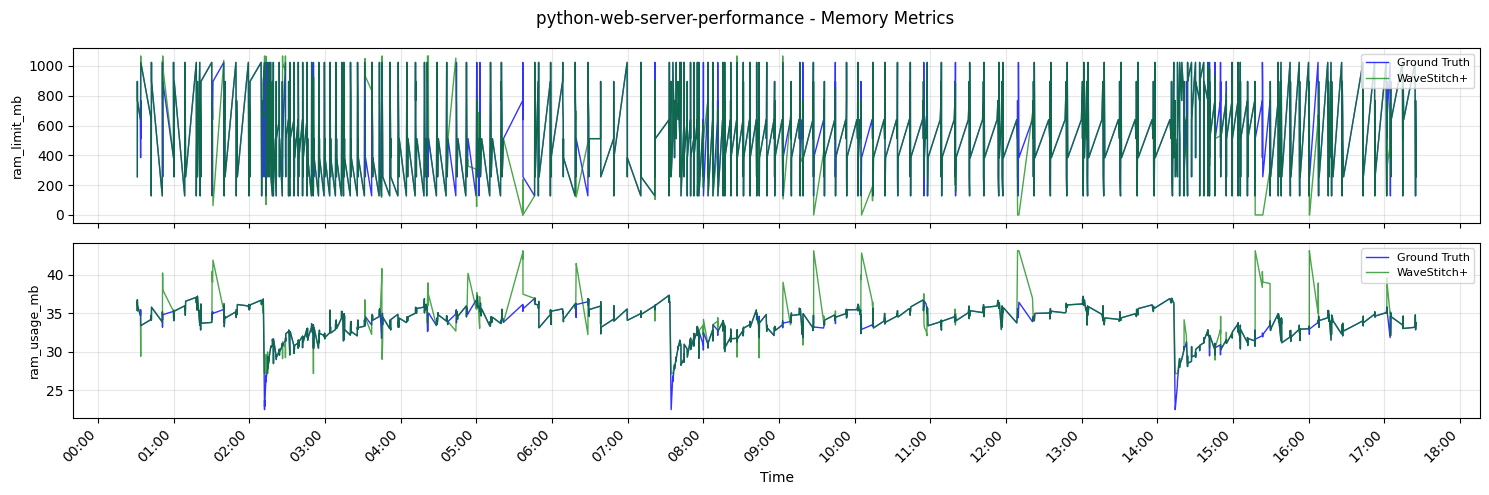

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/group_memory.png


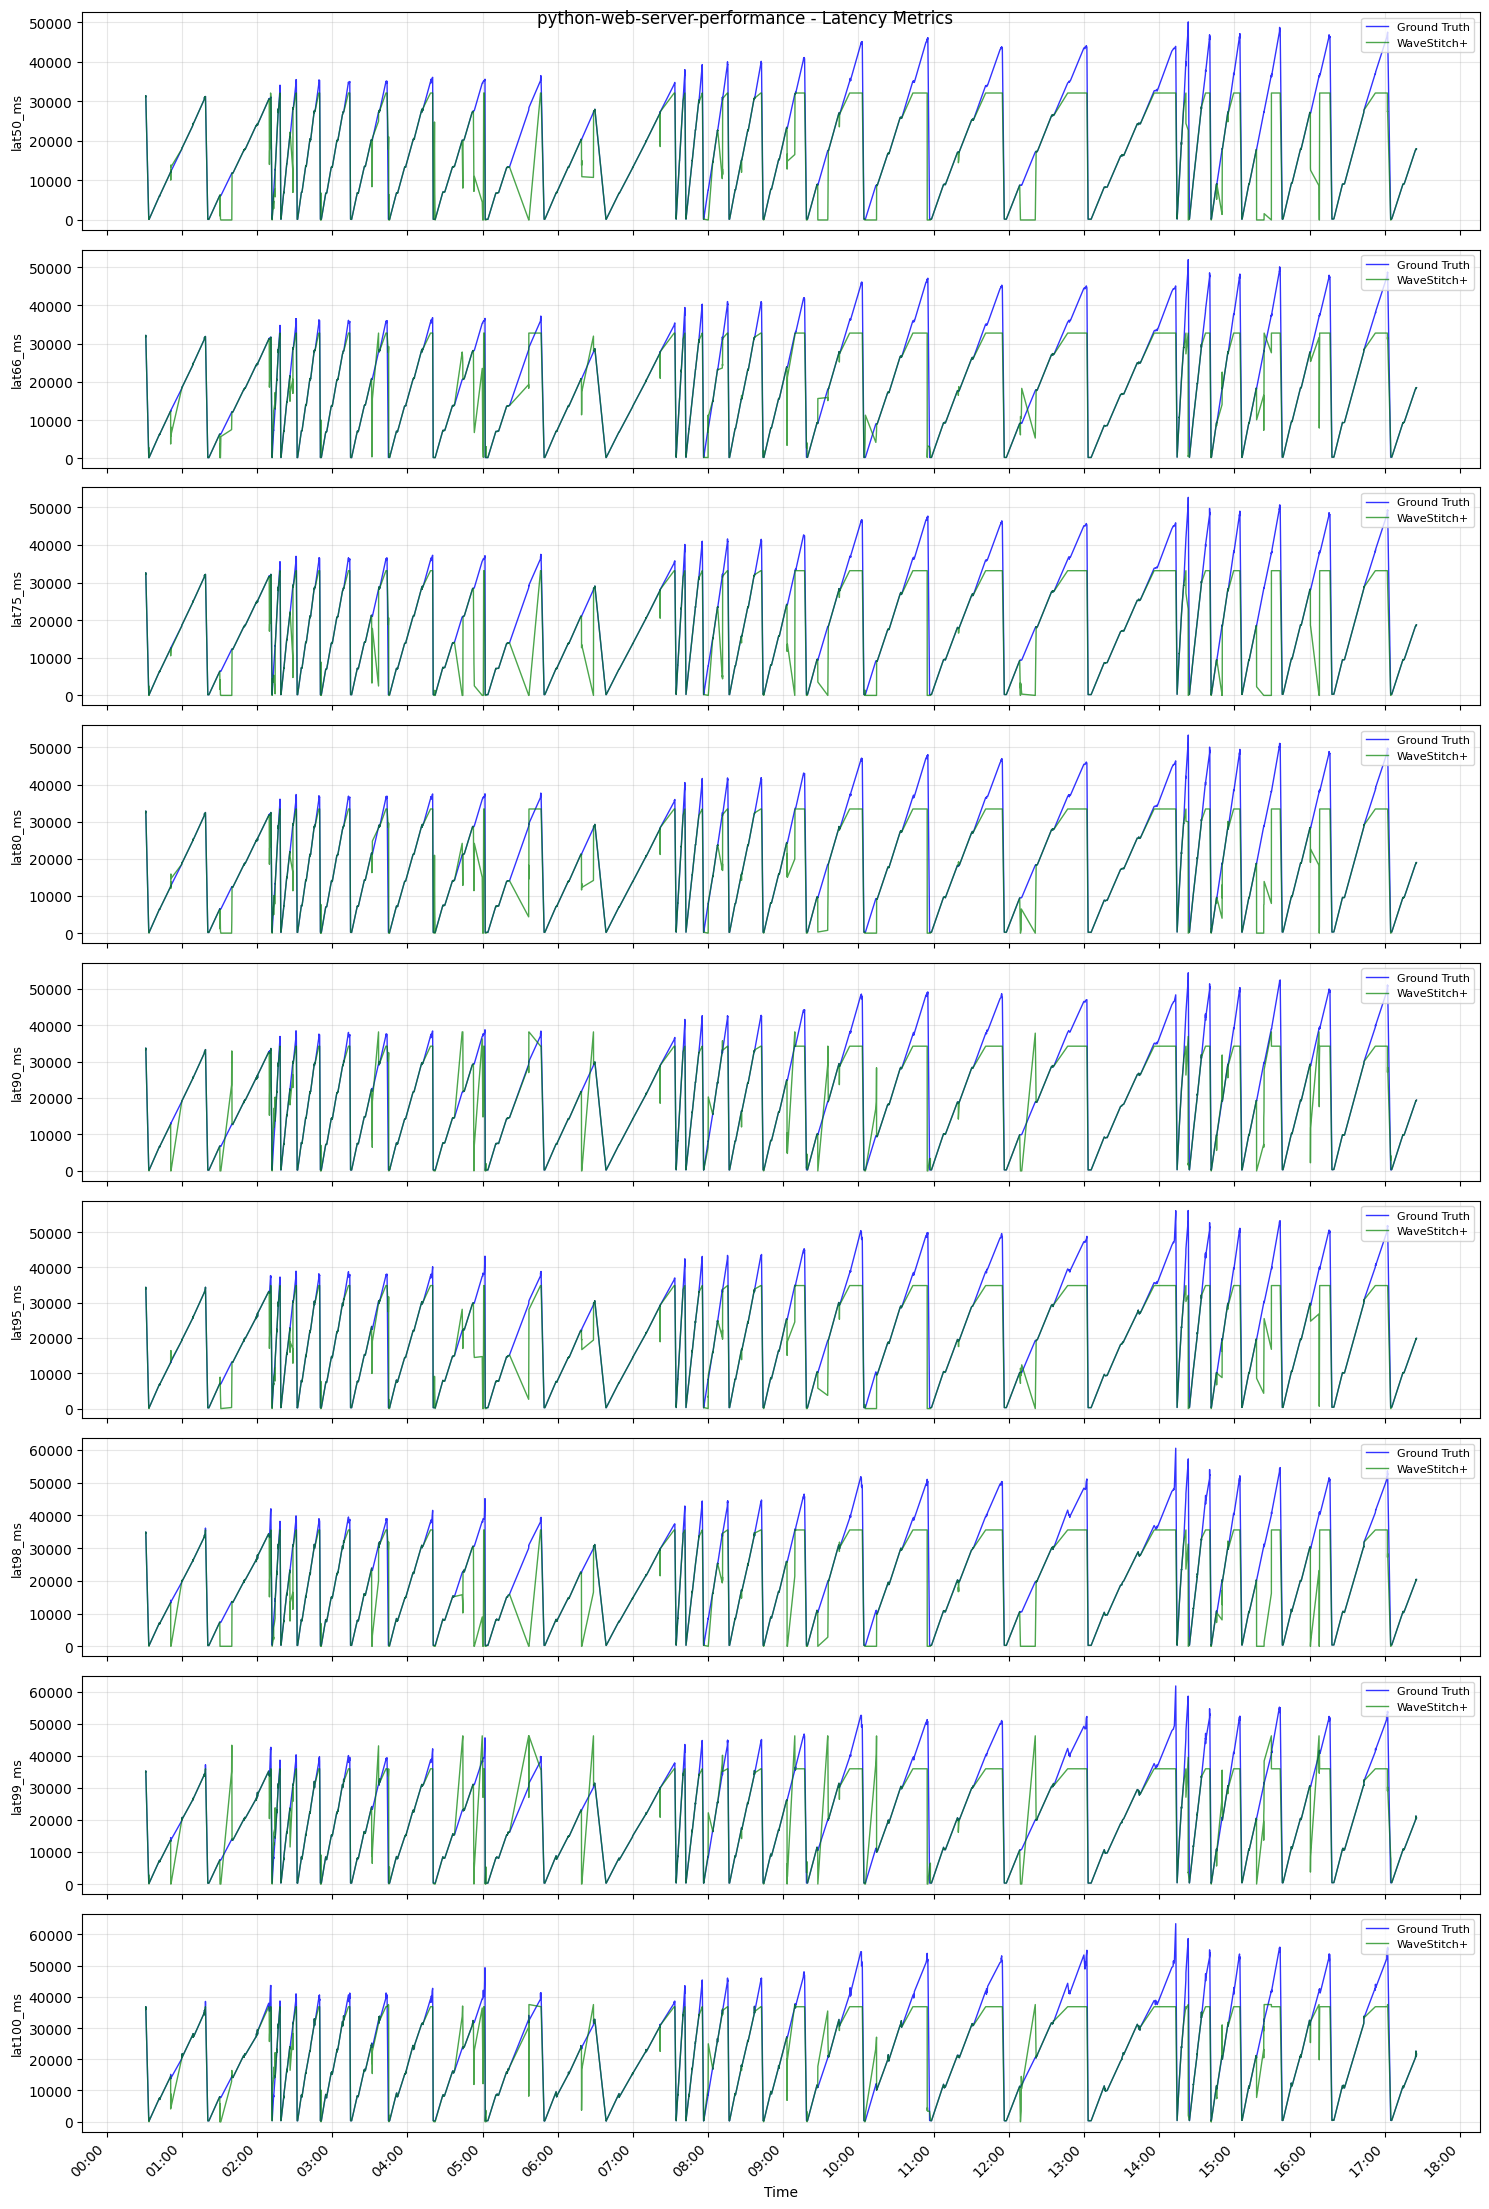

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/group_latency.png


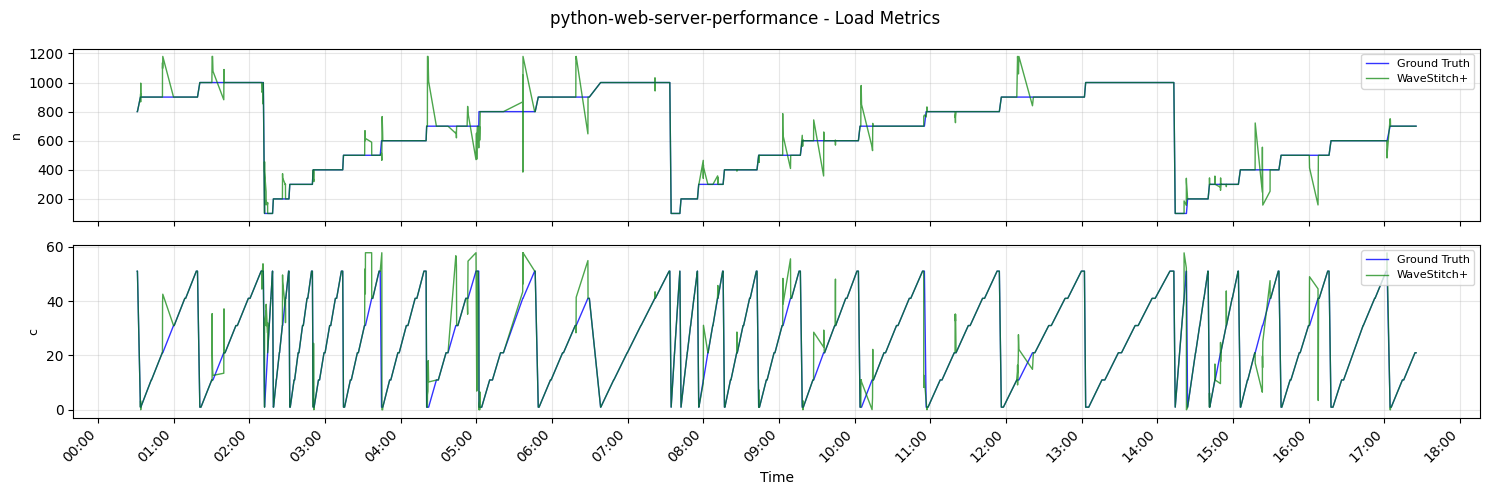

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots/group_load.png

[DONE] All plots saved to: ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/plots


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from datetime import datetime
import matplotlib.dates as mdates

# ============ 配置 ============

# datafilename  = "amf-performance"
# timeline = "manual__2026-02-25T08:12:38.806990+00:00"

# datafilename  = "rabbitmq-performance"
# timeline = "manual__2026-02-25T07:39:18.669633+00:00"

# datafilename  = "golang-web-server-performance"
# timeline = "manual__2026-02-25T08:23:29.080265+00:00"

datafilename  = "python-web-server-performance"
timeline = "manual__2026-02-25T09:30:58.766370+00:00"

base_dir = f'./EUR'
# prepared_dir = f'{base_dir}/wavestitchplus/{datafilename}'
prepared_dir = f"{base_dir}/wavestitchplus/{datafilename}/{timeline}/prepared"
generated_dir = f'{base_dir}/curated/{datafilename}/{timeline}/'
final_cleaned_dir = f'{base_dir}/cleaned/{datafilename}/{timeline}/'
# exit()
# ============ 从 meta.json 读取配置 ============
meta_path = os.path.join(prepared_dir, 'meta.json')

with open(meta_path, 'r') as f:
    meta = json.load(f)

time_col = meta.get('time_col', 'time')
target_cols = meta.get('target_cols', [])
cond_cols = meta.get('cond_cols', [])

print(f"{'='*60}")
print(f"Loaded meta from: {meta_path}")
print(f"{'='*60}")
print(f"Time column: {time_col}")
print(f"Target columns ({len(target_cols)}): {target_cols}")
print(f"{'='*60}\n")

# ============ 加载数据 ============
gt = pd.read_csv(os.path.join(prepared_dir, 'test_gt.csv'))
# pred_wavestitch = pd.read_csv(os.path.join(generated_dir, 'wavestitch_full_imputed_cleaned.csv'))
pred_wavestitchPlus = pd.read_csv(os.path.join(generated_dir, 'data.csv'))
final_cleaned = pd.read_csv(os.path.join(final_cleaned_dir, 'cleaned.csv'))
# print(f"Data shapes: GT={gt.shape}, WaveStitch={pred_wavestitch.shape}, WaveStitch+={pred_wavestitchPlus.shape}")

# print(f"Data shapes: GT={gt.shape}, WaveStitch+={pred_wavestitchPlus.shape}")
print(f"Data shapes: GT={gt.shape}, WaveStitch+={pred_wavestitchPlus.shape}, Final cleaned={final_cleaned.shape}")

# ============ 处理时间列 ============
def parse_time_column(df, time_col):
    """
    解析时间列，支持多种格式：
    - Unix timestamp (秒或毫秒)
    - ISO 格式字符串
    - 其他常见日期格式
    """
    if time_col not in df.columns:
        print(f"[WARNING] Time column '{time_col}' not found, using index")
        return pd.to_datetime(range(len(df)), unit='s')
    
    time_data = df[time_col]
    
    # 检查数据类型和范围
    sample = time_data.dropna().iloc[0] if len(time_data.dropna()) > 0 else None
    print(f"[INFO] Time sample: {sample} (type: {type(sample).__name__})")
    
    try:
        # 尝试 1: Unix timestamp (秒)
        if pd.api.types.is_numeric_dtype(time_data):
            if time_data.max() > 1e12:  # 毫秒
                print("[INFO] Detected Unix timestamp (milliseconds)")
                return pd.to_datetime(time_data, unit='ms')
            else:  # 秒
                print("[INFO] Detected Unix timestamp (seconds)")
                return pd.to_datetime(time_data, unit='s')
        
        # 尝试 2: 字符串格式
        print("[INFO] Trying to parse as datetime string")
        return pd.to_datetime(time_data)
    
    except Exception as e:
        print(f"[WARNING] Failed to parse time: {e}, using index")
        return pd.to_datetime(range(len(df)), unit='s')

# 解析时间
time_index = parse_time_column(gt, time_col)
print(f"[INFO] Time range: {time_index.min()} to {time_index.max()}")
print(f"[INFO] Duration: {time_index.max() - time_index.min()}")

# ============ 绘图辅助函数 ============
def setup_time_axis(ax, time_index):
    """设置时间轴格式"""
    duration = time_index.max() - time_index.min()
    
    if duration.days > 30:
        # 超过一个月：显示日期
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    elif duration.days > 1:
        # 超过一天：显示日期和时间
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    elif duration.total_seconds() > 3600:
        # 超过一小时：显示时:分
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    else:
        # 少于一小时：显示时:分:秒
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
    
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ============ 创建输出目录 ============
output_dir = os.path.join(generated_dir, 'plots')
os.makedirs(output_dir, exist_ok=True)

# ============ 方法 1: 每个特征单独绘图 ============
print("\n[PLOTTING] Individual feature plots...")

for feature_name in target_cols:
    if feature_name not in gt.columns:
        print(f"[SKIP] {feature_name} not in GT")
        continue
    
    fig, ax = plt.subplots(figsize=(15, 4))
    
    # 绘制 Ground Truth
    ax.plot(time_index, gt[feature_name].values, 
            label='Ground Truth', alpha=0.8, color='blue', linewidth=1)
    
    # 绘制 WaveStitch
    # if feature_name in pred_wavestitch.columns:
        # ax.plot(time_index, pred_wavestitch[feature_name].values, 
                # label='WaveStitch', alpha=0.7, color='orange', linewidth=1)
    
    # 绘制 WaveStitch+
    if feature_name in pred_wavestitchPlus.columns:
        ax.plot(time_index, pred_wavestitchPlus[feature_name].values, 
                label='WaveStitch+', alpha=0.7, color='green', linewidth=1)
    
    # if feature_name in final_cleaned.columns:
    #     ax.plot(time_index, final_cleaned[feature_name].values,
    #             label="Final cleaned", alpha=0.7, color='orange', linewidth=1)
        
    ax.set_title(f'{feature_name} - {datafilename}')
    ax.set_xlabel('Time')
    ax.set_ylabel(feature_name)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 设置时间轴格式
    setup_time_axis(ax, time_index)
    
    plt.tight_layout()
    save_path = os.path.join(output_dir, f'{feature_name}.png')
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    
    print(f"[SAVED] {save_path}")


# ============ 方法 2: 子图网格 ============
print("\n[PLOTTING] Grid plot...")

n_features = len(target_cols)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows))
axes = axes.flatten()

for idx, feature_name in enumerate(target_cols):
    ax = axes[idx]
    
    if feature_name not in gt.columns:
        ax.set_visible(False)
        continue
    
    # Ground Truth
    ax.plot(time_index, gt[feature_name].values, 
            label='GT', alpha=0.8, color='blue', linewidth=0.8)
    
    # WaveStitch
    # if feature_name in pred_wavestitch.columns:
        # ax.plot(time_index, pred_wavestitch[feature_name].values, 
                # label='WS', alpha=0.6, color='orange', linewidth=0.8)
    
    # WaveStitch+
    if feature_name in pred_wavestitchPlus.columns:
        ax.plot(time_index, pred_wavestitchPlus[feature_name].values, 
                label='WS+', alpha=0.6, color='green', linewidth=0.8)
    
    # if feature_name in final_cleaned.columns:
    #     ax.plot(time_index, final_cleaned[feature_name].values,
    #             label="Final cleaned", alpha=0.7, color='orange', linewidth=1)
        
    ax.set_title(feature_name, fontsize=10)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # 简化的时间轴（子图中）
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)

# 隐藏多余的子图
for idx in range(len(target_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'{datafilename} - All Target Features', fontsize=14)
plt.tight_layout()
save_path = os.path.join(output_dir, 'all_features_grid.png')
plt.savefig(save_path, dpi=150)
plt.show()
plt.close()
print(f"[SAVED] {save_path}")


# ============ 方法 3: 按组绘图（自动分组） ============
def auto_group_features(feature_list):
    """根据列名自动分组"""
    groups = {
        'CPU': [],
        'Memory': [],
        'Latency': [],
        'Load': [],
        'Other': []
    }
    
    for f in feature_list:
        f_lower = f.lower()
        if 'cpu' in f_lower:
            groups['CPU'].append(f)
        elif 'ram' in f_lower or 'mem' in f_lower:
            groups['Memory'].append(f)
        elif 'lat' in f_lower:
            groups['Latency'].append(f)
        elif f_lower in ['n', 'c', 'qps', 'rps', 'requests']:
            groups['Load'].append(f)
        else:
            groups['Other'].append(f)
    
    return {k: v for k, v in groups.items() if v}

feature_groups = auto_group_features(target_cols)

print("\n[PLOTTING] Grouped plots...")
for group_name, features in feature_groups.items():
    features = [f for f in features if f in gt.columns]
    if not features:
        continue
    
    n_features_in_group = len(features)
    fig, axes = plt.subplots(n_features_in_group, 1, 
                              figsize=(15, 2.5 * n_features_in_group), 
                              sharex=True)
    
    if n_features_in_group == 1:
        axes = [axes]
    
    for ax, feature_name in zip(axes, features):
        # Ground Truth
        ax.plot(time_index, gt[feature_name].values, 
                label='Ground Truth', alpha=0.8, color='blue', linewidth=1)
        
        # WaveStitch
        # if feature_name in pred_wavestitch.columns:
            # ax.plot(time_index, pred_wavestitch[feature_name].values, 
                    # label='WaveStitch', alpha=0.7, color='orange', linewidth=1)
        
        # WaveStitch+
        if feature_name in pred_wavestitchPlus.columns:
            ax.plot(time_index, pred_wavestitchPlus[feature_name].values, 
                    label='WaveStitch+', alpha=0.7, color='green', linewidth=1)
        
        # if feature_name in final_cleaned.columns:
        #     ax.plot(time_index, final_cleaned[feature_name].values,
        #             label="Final cleaned", alpha=0.7, color='orange', linewidth=1)
        
        ax.set_ylabel(feature_name, fontsize=9)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # 只在最后一个子图设置时间轴
    setup_time_axis(axes[-1], time_index)
    axes[-1].set_xlabel('Time')
    
    fig.suptitle(f'{datafilename} - {group_name} Metrics', fontsize=12)
    plt.tight_layout()
    
    save_path = os.path.join(output_dir, f'group_{group_name.lower()}.png')
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()
    print(f"[SAVED] {save_path}")


# ============ 方法 4: 交互式缩放（可选） ============
def plot_interactive(feature_name, start_time=None, end_time=None):
    """
    绘制特定时间范围的数据（用于详细查看）
    
    用法:
        plot_interactive('cpu_usage')  # 全部数据
        plot_interactive('cpu_usage', '2022-03-16 10:00', '2022-03-16 12:00')  # 指定范围
    """
    if feature_name not in gt.columns:
        print(f"[ERROR] {feature_name} not found")
        return
    
    # 创建带时间索引的 DataFrame
    df_plot = pd.DataFrame({
        'time': time_index,
        'Ground Truth': gt[feature_name].values,
    })
    
    # if feature_name in pred_wavestitch.columns:
        # df_plot['WaveStitch'] = pred_wavestitch[feature_name].values
    
    if feature_name in pred_wavestitchPlus.columns:
        df_plot['WaveStitch+'] = pred_wavestitchPlus[feature_name].values

    # if feature_name in final_cleaned.columns:
    #     df_plot['Final_cleaned'] = final_cleaned[feature_name].values
    
    df_plot = df_plot.set_index('time')
    
    # 筛选时间范围
    if start_time:
        df_plot = df_plot[df_plot.index >= pd.to_datetime(start_time)]
    if end_time:
        df_plot = df_plot[df_plot.index <= pd.to_datetime(end_time)]
    
    # 绘图
    fig, ax = plt.subplots(figsize=(15, 5))
    
    df_plot.plot(ax=ax, alpha=0.8, linewidth=1)
    
    ax.set_title(f'{feature_name} - {datafilename}')
    ax.set_xlabel('Time')
    ax.set_ylabel(feature_name)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    setup_time_axis(ax, df_plot.index)
    
    plt.tight_layout()
    plt.show()

# 使用示例（取消注释运行）:
# plot_interactive('cpu_usage')
# plot_interactive('lat99_ms', '2022-03-16 10:00', '2022-03-16 18:00')


print(f"\n{'='*60}")
print(f"[DONE] All plots saved to: {output_dir}")
print(f"{'='*60}")